## **Project - Churn Prediction of a Bank**

## **Objectives**

- Identify the profile of customers at higher risk of churn.
- Identify which features are the strongests indicators of churning.
- Develop a machine learning model capable of predicting with high accuracy which clients will churn.

**Dataset:** 10.000 Clients  
**Target Variable:** `churn` (1 = Churn, 0 = No Churn)

## Dataset features:

- **customer_id**: Identification id of each customer
- **credit_score**: Credit score of each customer
- **country**: Country of residence of each customer.
- **gender**: Gender of each customer.
- **age**: Age of each customer
- **tenure**: Amount of years the client has an account in the bank
- **balance**: The account balance.
- **products_number**: Number of products from the bank.
- **credit_card**: Whether a customer has a credit card. 1 - Yes/ 0 - No
- **active_member**: Whether a customer is an active member of the bank. 1 - Active/0 - Inactive
- **estimated_salary**: Estimated salary of the customers.
- **churn**: 1 - Churn/ 0 - Not Churn



### Setting up the environment 


In [1]:
#Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

#Modeling and validation
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#Evaluation metrics - Classification
from sklearn.metrics import (
    roc_auc_score, precision_score, average_precision_score, classification_report,
    confusion_matrix, recall_score, precision_recall_curve, roc_curve, f1_score
)

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


In [2]:
#Importing the dataset
df = pd.read_csv("bank_customer_churn_prediction.csv")

In [3]:
#Viewing the first 
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
#Verifying the dimensions of the dataset
df.shape 

(10000, 12)

In [5]:
#Verifying the types of variables, in case of conversion
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [6]:
#Checking for null values and duplicated columns
df.isna().sum() 

df[df.duplicated()] 

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [7]:
#Removing unnecessary columns - customer_id
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])
    print("Column 'customer_id' removed.")
else:
    print("Column 'customer_id' not found.")
    
#Checking the columns
df.shape
    

Column 'customer_id' removed.


(10000, 11)

In [8]:
#Defining and validating the target variable - 'churn'
target = 'churn'

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in the dataset.")

print("Distribution of target variable:")
display(df[target].value_counts(dropna=False))
print("\nChurn Rate:")
print(df[target].mean().round(4))

#If 'churn' = 1 - The client ended the relationship with the bank 

Distribution of target variable:


churn
0    7963
1    2037
Name: count, dtype: int64


Churn Rate:
0.2037


In [9]:
#Separating the feature(x) and the target variable(y)
target = "churn"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [10]:
#Checking the integrity of the data 
assert X.shape[0] == y.shape[0], "Number of dimensions is unequal"
assert y.nunique() == 2, "Target isn't in binary"
print("Integrity is OK.")

Integrity is OK.


## Spliting Training/Testing

We separate 20% of the data for testing, using `stratify=y` to assure that the proportion of churn be preserved in both set, considering that the dataset is disbalanced. The entire EDA will be done **exclusively in the training set** to avoid data leakage

In [11]:
#Diving in training(80%) and testing(20%)
#Using 'stratify = y' to keep the 'churn' proportion in both sets
#The EDA will be done solely in the training set to avoid data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape, y_train.shape)
print("Testing :", X_test.shape, y_test.shape)
print("Churn Rate Training:", round(y_train.mean(), 4))
print("Churn Rate Testing:", round(y_test.mean(), 4))

Training: (8000, 10) (8000,)
Testing : (2000, 10) (2000,)
Churn Rate Training: 0.2037
Churn Rate Testing: 0.2035


In [12]:
# Quick validation of the split

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_train.shape[1] == X_test.shape[1] == 10

diff = abs(y_train.mean() - y_test.mean())
print(f"Difference between training vs testing churn rate: {diff:.4f}")
assert diff < 0.01

Difference between training vs testing churn rate: 0.0003


In [13]:
#Training dataset for EDA 
train_df = pd.concat([X_train, y_train], axis=1).copy()
train_df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
2151,753,France,Male,57,7,0.00,1,1,0,159475.08,1
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25,0
4117,561,France,Male,37,5,0.00,2,1,0,83093.25,0
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99,0


In [14]:
#Consulting the churn rate in the training set
churn_rate = train_df[target].mean()
print(f"Churn Rate (training): {churn_rate:.2%}")

display(train_df[target].value_counts())
display((train_df[target].value_counts(normalize=True) * 100).round(2).rename("percentage"))

Churn Rate (training): 20.38%


churn
0    6370
1    1630
Name: count, dtype: int64

churn
0    79.62
1    20.38
Name: percentage, dtype: float64

## Exploratory Data Analysis(EDA)
This dataset has a churn rate of approximately 20%, indicating an moderately imbalanced dataset. This information will be relevant for the choices in the modeling phase of the project.
We will explore the most important variables in relation to churn, in order to understand what are the client profiles most likely to churn.

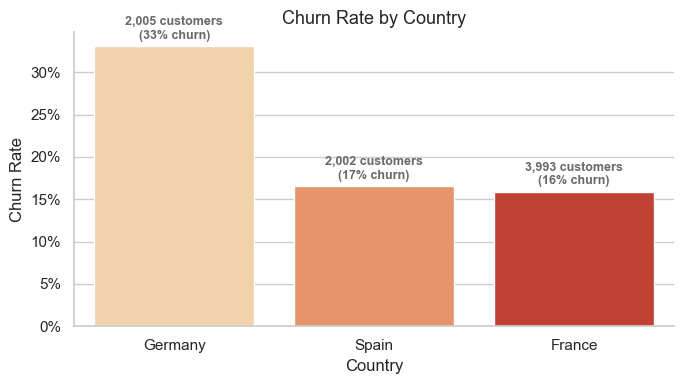

In [15]:
# Churn rate by country
q_country = (
    train_df
    .groupby("country")[target]
    .agg(churn_rate="mean", n_clients="count")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=q_country,
    x="country", y="churn_rate",
    hue="country",
    palette="OrRd",
    legend=False,
    ax=ax
)

for bar, row in zip(ax.patches, q_country.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row.n_clients:,} customers\n({row.churn_rate:.0%} churn)",
        ha="center", va="bottom", fontsize=9, color="dimgray", fontweight="bold"
    )

ax.set_title("Churn Rate by Country", fontsize=13)
ax.set_xlabel("Country")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
plt.show()

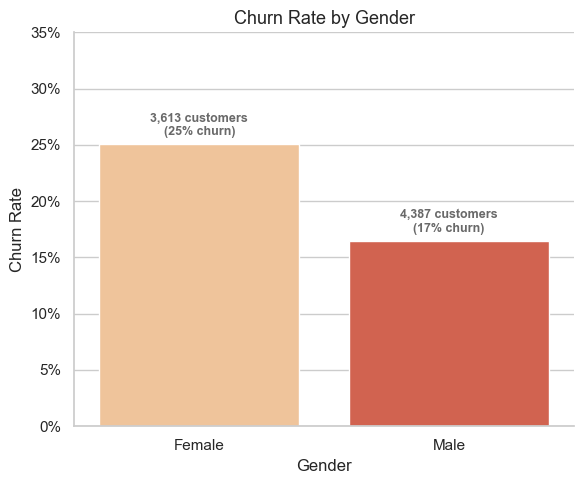

In [16]:
q_gender = (
    train_df
    .groupby("gender", observed=True)[target]
    .agg(churn_rate="mean", n_clientes="count")
    .reset_index() 
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data=q_gender,
    x="gender", y="churn_rate",
    hue="gender",
    palette="OrRd",
    legend=False,
    ax=ax
)

ax.set_ylim(0, 0.35)  

for bar, row in zip(ax.patches, q_gender.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row.n_clientes:,} customers\n({row.churn_rate:.0%} churn)",
        ha="center", va="bottom", fontsize=9, color="dimgray", fontweight="bold"
    )

ax.set_title("Churn Rate by Gender", fontsize=13)
ax.set_xlabel("Gender")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
plt.show()

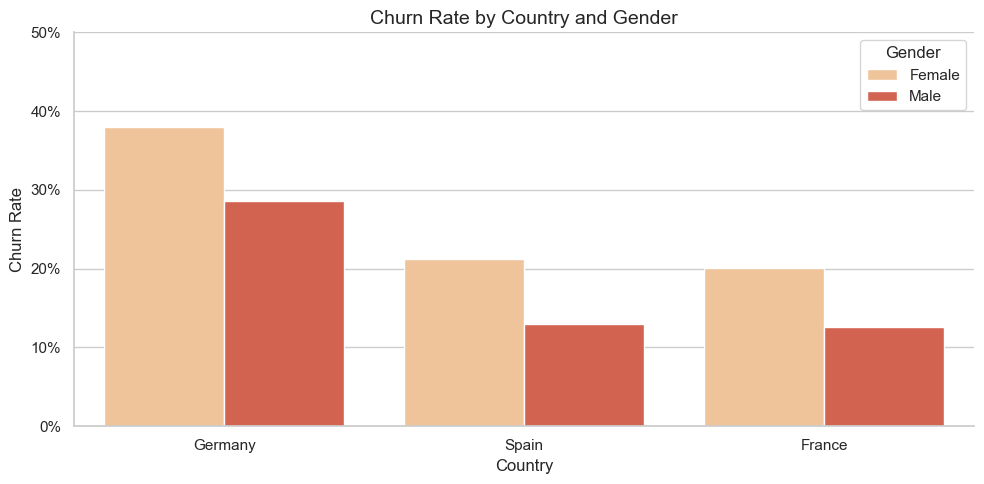

In [17]:
# Bivariate Analysis - Country and Gender
q2 = (
    train_df
    .groupby(["country", "gender"])[target]
    .agg(churn_rate="mean", n_clientes="count")
    .query("n_clientes >= 50")
    .sort_values("churn_rate", ascending=False)
)

q2_plot = q2.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=q2_plot,
    x="country", y="churn_rate",
    hue="gender",
    palette="OrRd",
    ax=ax
)

ax.set_title("Churn Rate by Country and Gender", fontsize=14)
ax.set_xlabel("Country")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, 0.50)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(title="Gender")
sns.despine()
plt.tight_layout()
plt.show()

### Country and Gender
- Germany is the country with the highest churn rate(~32%), followed by France and Spain with considerably lower rates(16%), this is notable considering that France has about twice the amount of customers that the other two countries, showing that group has a lower risk. This patterns sugests that regional features, such as market competition, regulation or quality of service may have impact in such difference.

- Women present the largest churn rate in gender(25%) in comparison to men, despite having less consumers than them.

**Highest Risk Costumer**: German/Woman
**Lowest Risk Costumer**: French/Man
**Hypothesis**: Country and Gender may be relevant features to this model.

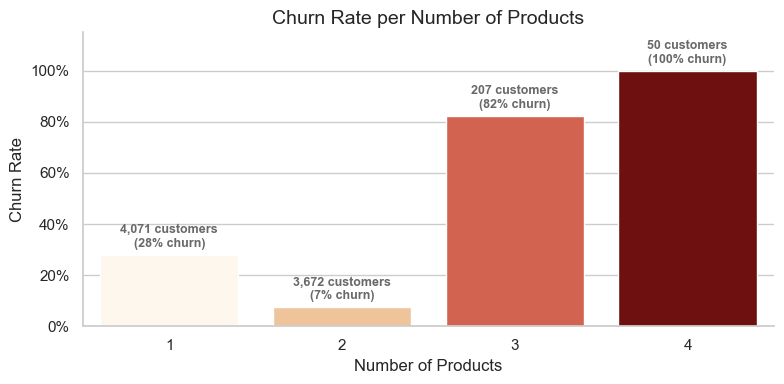

In [18]:
q_num_produc = (
    train_df
    .groupby("products_number")[target]
    .agg(churn_rate="mean", n_clients="count")
    .sort_values("products_number")  # ordena por número de produto, não por churn
)

q_num_produc_plot = q_num_produc.reset_index()

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=q_num_produc_plot,
    x="products_number", y="churn_rate",
    hue="products_number",
    palette="OrRd",
    legend=False,
    ax=ax
)

ax.set_ylim(0, 1.15) 

for bar, row in zip(ax.patches, q_num_produc_plot.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{row.n_clients:,} customers\n({row.churn_rate:.0%} churn)",
        ha="center", va="bottom", fontsize=9, color="dimgray", fontweight="bold"
    )

ax.set_title("Churn Rate per Number of Products", fontsize=14)
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
plt.show()

### Number of products x Churn Rate

- Clients that consume 1 product have a moderate churn(~28%), meanwhile clients with 2 products are the most loyal (~8%). Simultaneously when clients consume 3 products or more there is a significant increase in churn: 83% of clients with 3 products, while clients with 4 products praticaly 100% leave the bank. However, it's important to consider the possibility of statistical noise, considering that the sample size drasticaly discrease when clients use 3 products or more.

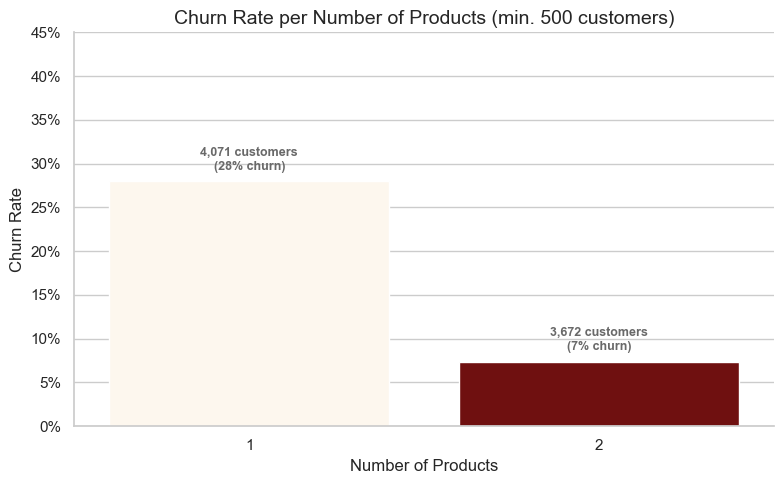

In [19]:
q_num_produc_filtered = (
    train_df
    .groupby("products_number")[target]
    .agg(churn_rate="mean", n_clients="count")
    .query("n_clients >= 500")
    .sort_values("products_number")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=q_num_produc_filtered,
    x="products_number", y="churn_rate",
    hue="products_number",
    palette="OrRd",
    legend=False,
    ax=ax
)

ax.set_ylim(0, 0.45)

for bar, row in zip(ax.patches, q_num_produc_filtered.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{row.n_clients:,} customers\n({row.churn_rate:.0%} churn)",
        ha="center", va="bottom", fontsize=9, color="dimgray", fontweight="bold"
    )

ax.set_title("Churn Rate per Number of Products (min. 500 customers)", fontsize=14)
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
plt.show()

- To better show how most of the clients behave, we created a filter of at least 500 consumers to consider as relevant to the graph.

- As noted previously, the most common case are the customers who consume only a single product with about as many 4x more chance of churning in comparision to clients that use 2 products. This fact may sugest that cross-selling a second product may increase switching costs and deepen the relationship between the bank and customer.

In [20]:
train_df["age_bin"] = pd.cut(
    train_df["age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

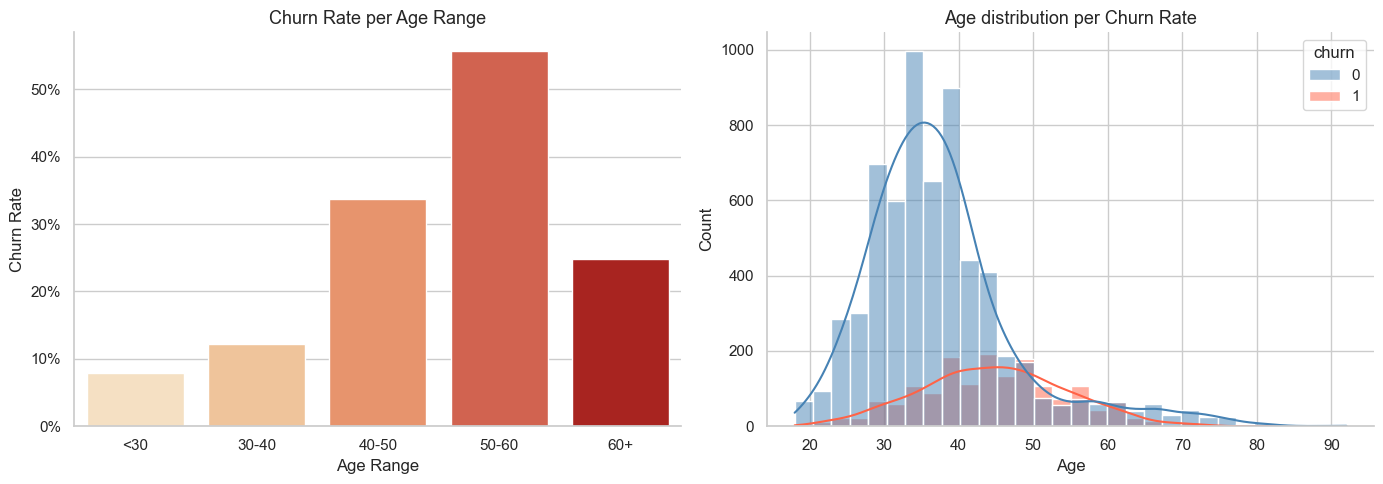

In [21]:
q_age = (
    train_df
    .groupby("age_bin", observed=True)[target]
    .agg(churn_rate="mean", n_clientes="count")
    .sort_values("churn_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q_age_plot = q_age.reset_index().sort_values("age_bin")

sns.barplot(
    data=q_age_plot,
    x="age_bin", y="churn_rate",
    hue="age_bin",
    palette="OrRd",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Churn Rate per Age Range", fontsize=13)
axes[0].set_xlabel("Age Range")
axes[0].set_ylabel("Churn Rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

sns.histplot(
    data=train_df,
    x="age", hue="churn",
    bins=30, kde=True,
    palette={0: "steelblue", 1: "tomato"},
    ax=axes[1]
)
axes[1].set_title("Age distribution per Churn Rate", fontsize=13)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

sns.despine()
plt.tight_layout()
plt.show()

### Age Range

- Churn grows consistently with age up to the 50-60 cohort, where it reaches its peak. Customers under 30 have the lowest churn rate, possibly because they are more 'capturable' with digital services or because they do not yet have enough assets to migrate to other services.

- The histogram confirms that the age distribution of churned customers is right-shifted compared to those who stay. The difference becomes visually clear between 40 and 60 years old.

- **Possible Hypothesis:** Clients from older age ranges may have more significant amount of assets, making them more sensible to the quality of service and an more acess to wide range of options of products from others banks.

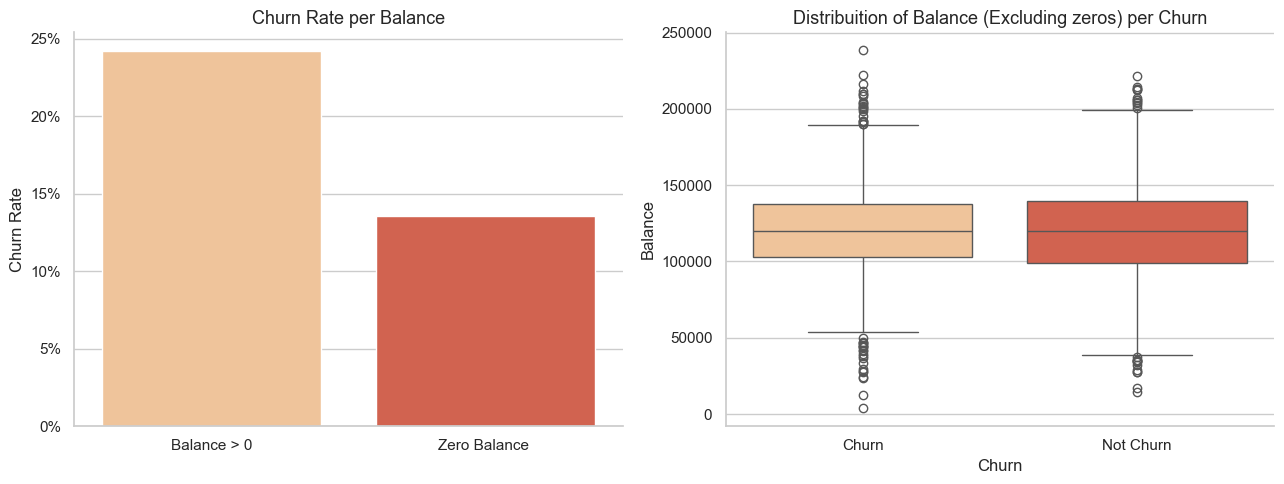

In [22]:
train_df["zero_balance"] = (train_df["balance"] == 0).astype(int)

q_balance = (
    train_df
    .groupby("zero_balance")[target]
    .agg(churn_rate="mean", n_clientes="count")
    .sort_values("churn_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

q_balance_plot = q_balance.reset_index()
q_balance_plot["zero_balance_label"] = q_balance_plot["zero_balance"].map({1: "Zero Balance ", 0: "Balance > 0"})

sns.barplot(
    data=q_balance_plot,
    x="zero_balance_label", y="churn_rate",
    hue="zero_balance_label",
    palette="OrRd",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Churn Rate per Balance", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn Rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

balance_df = train_df[train_df["balance"] > 0].copy()
balance_df["churn_label"] = balance_df["churn"].map({0: "Not Churn", 1: "Churn"})

sns.boxplot(
    data=balance_df,
    x="churn_label", y="balance",
    hue="churn_label",
    palette="OrRd",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribuition of Balance (Excluding zeros) per Churn", fontsize=13)
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Balance")

sns.despine()
plt.tight_layout()
plt.show()

### Balance
- Counterintuitively, customers with a positive balance have a higher churn rate than customers with a zero balance (~22% vs ~14%). The boxplot shows that the balance distribution among churned customers is slightly higher than among those who stayed.

- This raises an important hypothesis: customers with higher assets may be migrating to institutions with more competitive offerings (lower fees, higher returns). Customers with a zero balance, on the other hand, may have less incentive or capacity to migrate.


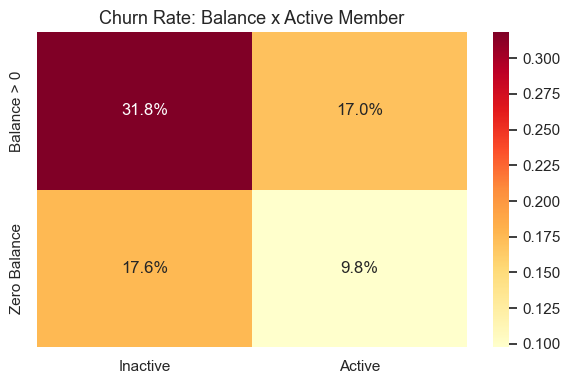

In [23]:
contingency = pd.crosstab(
    train_df["zero_balance"],
    train_df["active_member"],
    values=train_df["churn"],
    aggfunc="mean"
).round(3)

contingency.index = ["Balance > 0", "Zero Balance"]
contingency.columns = ["Inactive", "Active"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(contingency, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax)
ax.set_title("Churn Rate: Balance x Active Member", fontsize=13)
plt.tight_layout()
plt.show()

##  Balance x Active Member
- This confirms the previous hypothesis that inactive customers with positive balances have the highest churn rate (31.8%), nearly double that of inactive customers with a zero balance. This is one of the primary profiles drifting away from the bank.
- Active customers with a zero balance are the group with the lowest churn probability (9.8%)
- **Hypothesis**: These customers use their checking accounts for daily transactions, where salaries are received and expenses are paid, consistently driving the balance close to zero. On the other hand, inactive customers with balances above zero might simply be keeping their funds in the bank due to inertia without consuming products, making them a high-risk group for churn.

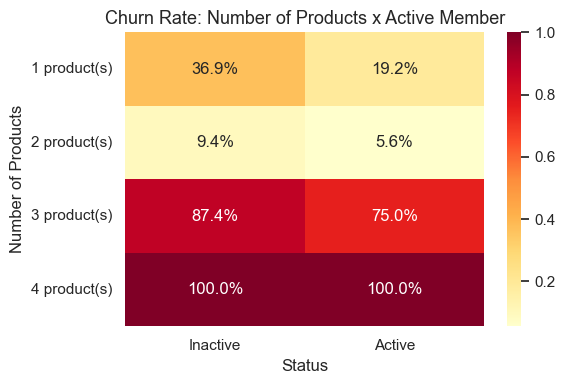

In [24]:
contingency_prod = pd.crosstab(
    train_df["products_number"],
    train_df["active_member"],
    values=train_df["churn"],
    aggfunc="mean"
).round(3)

contingency_prod.index = [f"{p} product(s)" for p in contingency_prod.index]
contingency_prod.columns = ["Inactive", "Active"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(contingency_prod, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax)
ax.set_title("Churn Rate: Number of Products x Active Member", fontsize=13)
ax.set_xlabel("Status")
ax.set_ylabel("Number of Products")
plt.tight_layout()
plt.show()

### Number of Products x Active Member
- It confirms that customers with 2 products are the most loyal segment regardless of 
  activity status, making two products the ideal level of engagement with the bank.
- It also confirms that churn increases dramatically at 3 or more products, which may 
  point to dissatisfaction with product quality or customers already in the process of leaving.
- However, given the small size of the 3–4 product groups, inactive customers holding 
  only 1 product represent the most significant at-risk segment in practice, most likely 
  reflecting low-engagement clients with weak ties to the bank, whether due to 
  dissatisfaction or use of the account as a secondary option.

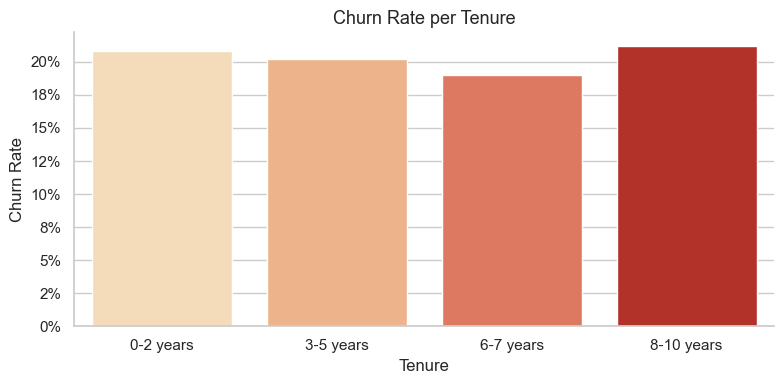

In [25]:
train_df["tenure_bin"] = pd.cut(
    train_df["tenure"],
    bins=[-1, 2, 5, 7, 10],
    labels=["0-2 years", "3-5 years", "6-7 years", "8-10 years"]
)

q_tenure = (
    train_df
    .groupby("tenure_bin", observed=True)[target]
    .agg(churn_rate="mean", n_clientes="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=q_tenure,
    x="tenure_bin", y="churn_rate",
    hue="tenure_bin",
    palette="OrRd",
    legend=False,
    ax=ax
)
ax.set_title("Churn Rate per Tenure", fontsize=13)
ax.set_xlabel("Tenure")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
plt.show()

### Tenure
The tenure with the bank doesn't present as an expressive variable to the churn rate amongst the groups, with all of the ranges having rates of around 20%. Suggesting that, in isolation, this variable carries little weight for the predictive model.

Regardless, it's noteworthy that the highest values belong to opposing groups. Customers who terminate their relationship within the first 2 years may indicate dissatisfaction with the initial experience. Meanwhile, long-term customers with over 8 years of relationship exhibit the highest churn rate. Althought this may appear counterintuitive, it could potentialy correlate with the fact that the audience at highest risk of churn consists of customers with a positive balance who do not consume products. These customers likely maintain their accounts merely due to inertia.


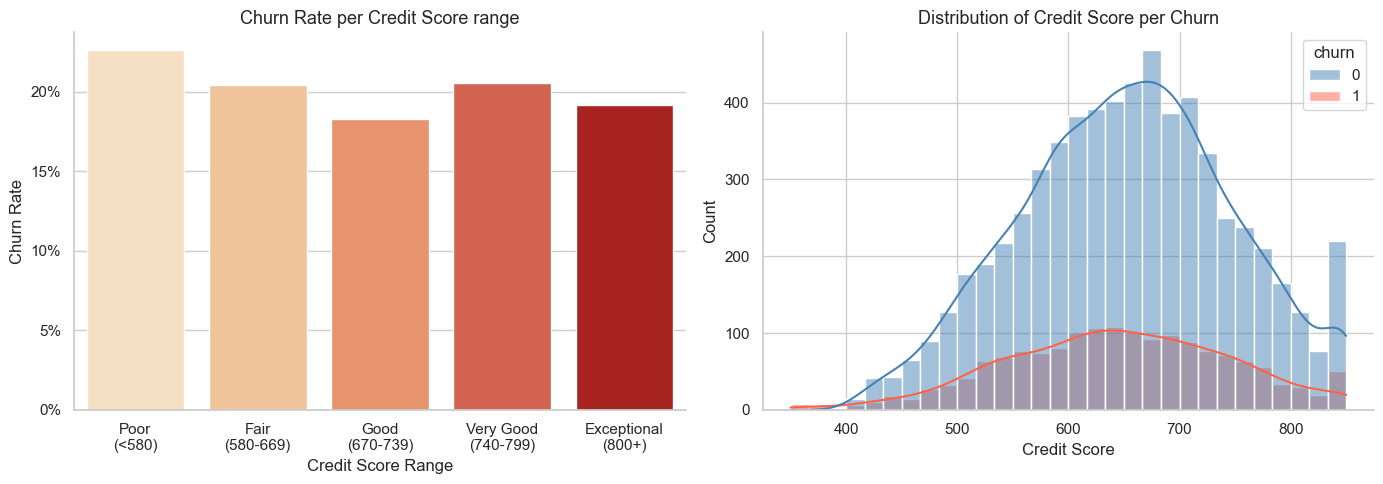

In [26]:
train_df["credit_bin"] = pd.cut(
    train_df["credit_score"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=["Poor\n(<580)", "Fair\n(580-669)", "Good\n(670-739)", "Very Good\n(740-799)", "Exceptional\n(800+)"]
)

q_credit = (
    train_df
    .groupby("credit_bin", observed=True)[target]
    .agg(churn_rate="mean", n_clients="count")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=q_credit,
    x="credit_bin", y="churn_rate",
    hue="credit_bin",
    palette="OrRd",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Churn Rate per Credit Score range", fontsize=13)
axes[0].set_xlabel("Credit Score Range")
axes[0].set_ylabel("Churn Rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

sns.histplot(
    data=train_df,
    x="credit_score", hue="churn",
    bins=30, kde=True,
    palette={0: "steelblue", 1: "tomato"},
    ax=axes[1]
)
axes[1].set_title("Distribution of Credit Score per Churn", fontsize=13)
axes[1].set_xlabel("Credit Score")
axes[1].set_ylabel("Count")

sns.despine()
plt.tight_layout()
plt.show()

### Churn Rate x Credit Score
- Considering the dataset didn't specify which scoring methodology is used by the bank, we have chosen the standart FICO framework, which is widely adopted credit scoring framework in the financial industry. It's divided in five possible classifications accordyling to credit score: Poor(<580), Fair(580-669), Good(670-739), Very Good(740-799) and Exceptional(+800)

- Interessing, in this dataset credit score doesn't seem to be a significant feature to churn, considering that across all groups that hasn't a significant variation (~18% - 22%), also the score distributions seem to overlap almost entirely in the histogram.

- This seems to sugest that credit score may be relevant to credit decisions, however it doesn't significantly drive customers to leave the bank.

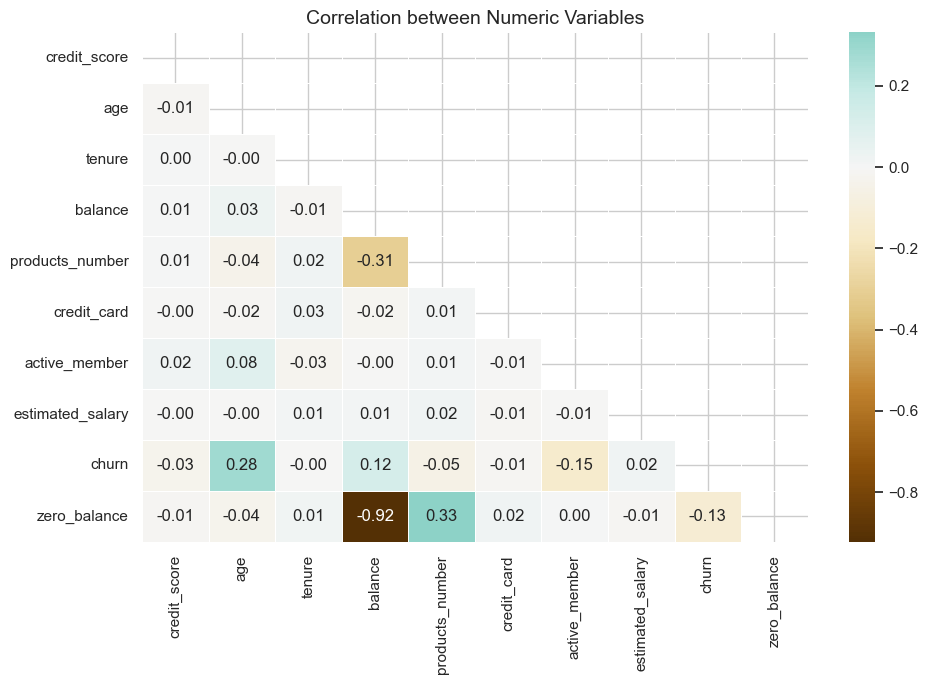

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

num_cols = train_df.select_dtypes(include="number").columns.tolist()

corr = train_df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="BrBG", center=0,
    linewidths=0.5, ax=ax
)

ax.set_title("Correlation between Numeric Variables", fontsize=14)
plt.tight_layout()
plt.show()

<br>

## Conclusions

#### Demographics
- German customers churn at almost twice the rate of French and Spanish customers, despite 
  France having a significantly greater amount of customers. That may suggest that regional 
  factors may be at play, such as local competition or product quality.
- Women also show a greater risk of churning in comparison to men, however, the rate isn't 
  as significant as the one by country.
- Age is among the most relevant individual predictors. The churn rate peaks in the 50-60 
  age range, where more than half of the customers in this group are leaving the bank. 
  Meanwhile, clients younger than 30 are the least likely to churn, which may be due to 
  fewer assets in comparison to older clients, resulting in greater difficulty in changing services.

#### Balance
- Customers with zero balance show a meaningful difference in behaviour in comparison to 
  other customers. Among customers with a positive balance, there is a noticeable relationship 
  between higher balance and a slightly higher churn rate, possibly reflecting clients with a 
  greater range of options exploring other services.

#### Number of Products
- The relationship between the number of products and the churn rate is interesting due to 
  its non-linearity. Customers with 2 products show the lowest churn rate, while customers 
  with 1 product and drastically at 3 products or higher show a considerably higher risk of 
  churn. The extreme values from clients with 3 or more products may reflect dissatisfaction 
  with the products or services, or even the possibility of forced acquisition of unwanted 
  products. It may also represent clients who are already in the process of leaving.

#### Active Membership
- Active customers are consistently less likely to churn in comparison to inactive customers. 
  Across all groups, a client being active decreases the churn rate uniformly, which suggests 
  that active membership amplifies the patterns present in other variables.
- The highest-risk group emerging from this analysis is an inactive client holding 1 product. 
  This group most likely represents customers with low engagement and weak ties to the bank, 
  whether due to dissatisfaction, unmet expectations, or simply using the account as a 
  secondary option.

#### Tenure
- No significant pattern was found within the tenure range; the churn rate remains consistent 
  among all tenure groups. This may suggest that within this dataset, the amount of time a 
  customer has spent with the bank does not yield customer loyalty.

#### Credit Score
- There was also no noticeable trend among the credit score groups, with rates varying around 
  18% to 22%. This may suggest that credit score won't be a significant feature for the 
  predictive model.

<br>

### Customer Risk
- Combining the most relevant findings, the highest-risk churn profile is a middle-aged woman based in Germany, with a positive balance, inactive status, and either a single product or three or more products. This profile concentrates the key risk factors identified throughout the analysis. 

<br>

## Pre-Processing
Based on the EDA, the variables were divided into three groups for appropriate handling:

- **Numerical**: Will receive imputations throught the median and standardization (StandartScaler)
- **Categorical**: Will receive imputations throught the mode and codification (OneHotEnconder)
- **Binary**: Will bypass transformation, due to already being in an 0/1 scale


The entire preprocessing workflow is encapsulated within a *Pipeline* with *ColumnTransformer* , this is done in order to ensure that the transformations are learned strictly in the training set and correctly applied in the testing set.

In [28]:
cat_cols = ["country", "gender"]

num_cols = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "estimated_salary"
]

binary_cols = ["credit_card", "active_member"]

print("Categorical:", cat_cols)
print("Numerical:", num_cols)
print("Binary:", binary_cols)


Categorical: ['country', 'gender']
Numerical: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
Binary: ['credit_card', 'active_member']


<br>

#### Creating the pipeline:

In [29]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
    ("bin", "passthrough", binary_cols)
])

In [30]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="saga",           
        random_state=RANDOM_STATE
    ))
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipe_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric="auc",
        n_jobs=-1
    ))
])

<br>


#### Searching for the best hyperparameters

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 0.5, 1],  
    "model__solver": ["saga"],       
    "model__max_iter": [1000],
}

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

param_xgb = {
    "model__n_estimators":    [100, 200, 300],
    "model__max_depth":       [3, 5, 7],
    "model__learning_rate":   [0.01, 0.05, 0.1],
    "model__subsample":       [0.7, 0.9, 1.0],
    "model__colsample_bytree":[0.7, 0.9, 1.0]
}

<br>

## Modeling

We have test three different classifications models with distinct levels of complexity: Logistic Regression (Linear model), Random Florest (Non-linear ensemble) and XGBoost(Gradient boosting)

In order to work with our imbalanced dataset, we have adjusted our sample weights inversely proportional to class frequency within the Logistic Regression and Random Florest Model, which is the *class_weight = "balanced"*. Meanwhile with the XGBoost, we have used an equivalent method with *scale_pos_weight*, set as the ratio of negative to positive samples.



In [32]:
searches = {
    "Logistic Regression": (pipe_lr, param_lr, 10),
    "Random Forest":       (pipe_rf, param_rf, 20),
    "XGBoost":             (pipe_xgb, param_xgb, 20),
}

fitted_searches = {}

for name, (pipe, params, n_iter) in searches.items():
    print(f"\nTraining: {name}...")
    search = RandomizedSearchCV(
        pipe,
        param_distributions=params,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    fitted_searches[name] = search
    print(f"  Best AUC-ROC score : {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

search_lr  = fitted_searches["Logistic Regression"]
search_rf  = fitted_searches["Random Forest"]
search_xgb = fitted_searches["XGBoost"]


Training: Logistic Regression...
  Best AUC-ROC score : 0.7677
  Best params: {'model__solver': 'saga', 'model__max_iter': 1000, 'model__l1_ratio': 0.5, 'model__C': 0.01}

Training: Random Forest...
  Best AUC-ROC score : 0.8576
  Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10}

Training: XGBoost...
  Best AUC-ROC score : 0.8647
  Best params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


<br>

In [33]:
y_prob_lr  = search_lr.predict_proba(X_test)[:, 1]
y_prob_rf  = search_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = search_xgb.predict_proba(X_test)[:, 1]


y_pred_lr  = search_lr.predict(X_test)
y_pred_rf  = search_rf.predict(X_test)
y_pred_xgb = search_xgb.predict(X_test)

In [34]:
def model_summary(name, y_true, y_prob, y_pred):
    return {
        "Model": name,
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "AUC-PR": round(average_precision_score(y_true, y_prob), 4),
        "Precision (Churn)": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall (Churn)": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1 (Churn)": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results_table = pd.DataFrame([
    model_summary("Logistic Regression", y_test, y_prob_lr,  y_pred_lr),
    model_summary("Random Forest",       y_test, y_prob_rf,  y_pred_rf),
    model_summary("XGBoost",             y_test, y_prob_xgb, y_pred_xgb),
])

results_table = results_table.set_index("Model")

display(results_table.style.highlight_max(axis=0, color="lightgreen"))

,AUC-ROC,AUC-PR,Precision (Churn),Recall (Churn),F1 (Churn)
Model,,,,,
Logistic Regression,0.780400,0.458300,0.398400,0.712500,0.511000
Random Forest,0.859900,0.686700,0.590100,0.675700,0.630000
XGBoost,0.866500,0.715900,0.503300,0.754300,0.603700


<br>

### Main Metrics
- As shown in the comparison table, XGBoost achieved the best overall performance, particularly on the most relevant metrics for imbalanced churn data such as Recall(0.75), AUC-ROC(0.86) and AUC-PR(0.71). Meaning that in 75% of cases the model has able to sucessfully identify customers who churned.
- Random Florest perfomed competitively, outperfoming XGBoost in the Precision(0.59) and F1(0.63) metrics. Which may suggest an more conservative approach in labelling customers as churners, however this could cost an increased amount of missed real churners.
- Logistic Regression underperfomed in across all metrics, most likely due to the non-linear relationship between the variables. While it still achieved an 0.78 AUC-ROC, it fell short compared to the other models.

<br>

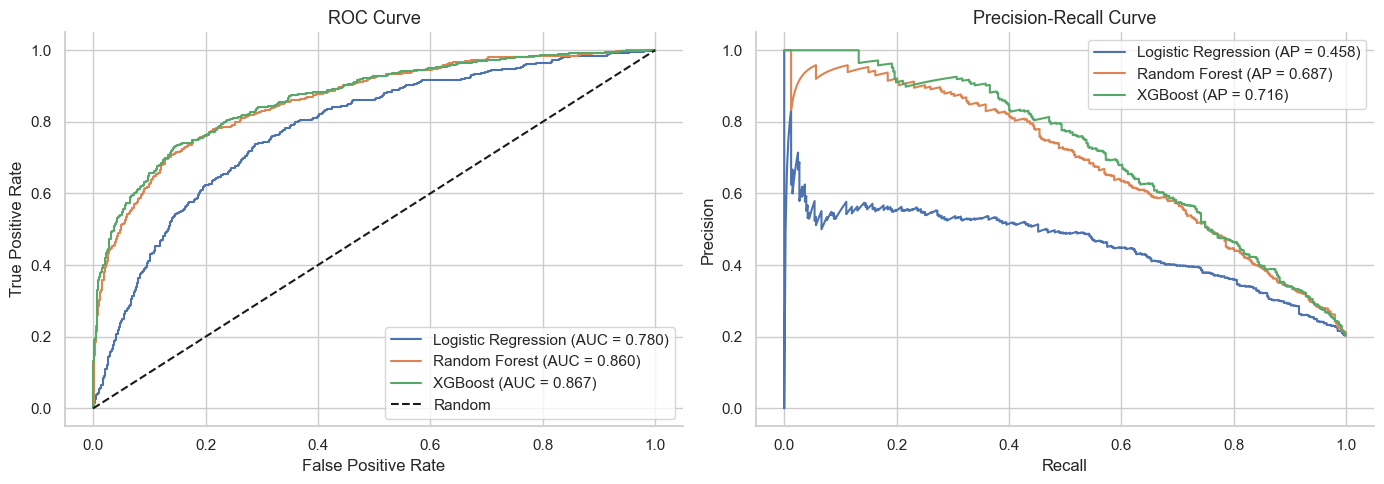

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest",       y_prob_rf),
    ("XGBoost",             y_prob_xgb)
]

for name, y_prob in models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
sns.despine()

for name, y_prob in models:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (AP = {ap:.3f})")

axes[1].set_title("Precision-Recall Curve", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
sns.despine()

plt.tight_layout()
plt.show()

<br>

### ROC Curve and Precision-Recall
- Both ROC Curve and Precision-Recall Curve show the Random Florest and XGBoost consistently outperfoming the Logistic Regression model. With the ROC Curve, both Random Florest(0.860) and XGBoost(0.867) have an similar perfomance, while Logistic Regression(0.78) falls short behind.
- The Precision-Recall shows an even clearer story considering the class imbalance. While XGBoost(0.716) and Random Florest(0.687) show an high precision even at moderate recall levels, the Logistic Regression drops significantly, confirming that the model struggles to consistently identify churners without generating an meaningful amount of false positives(Clients that are identified as churners but don't really churn).

<br>

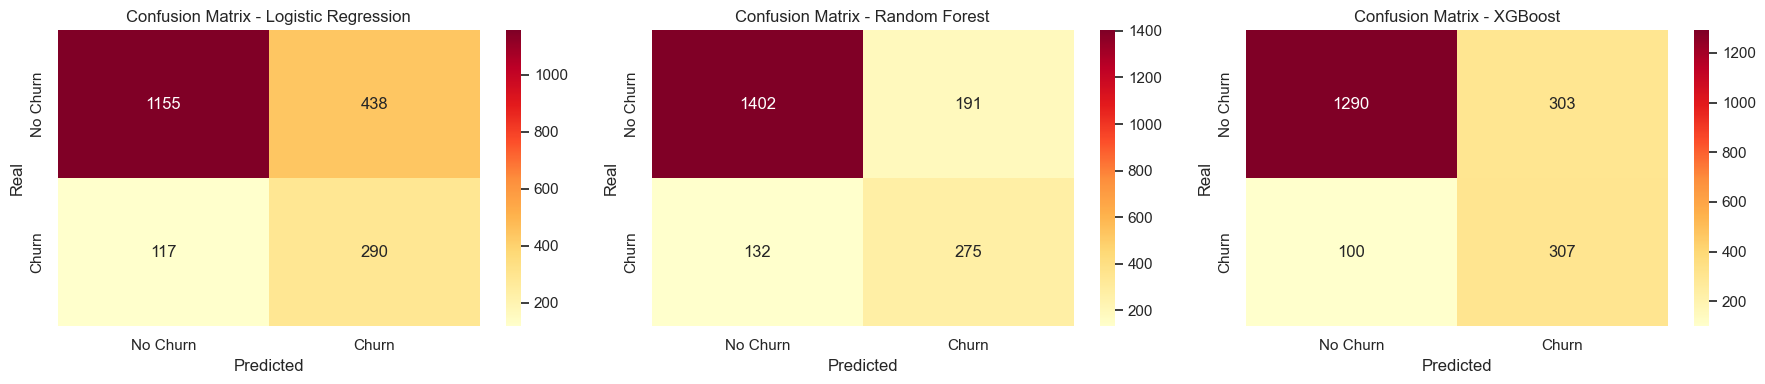

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name, y_pred in zip(
    axes,
    ["Logistic Regression", "Random Forest", "XGBoost"],
    [y_pred_lr, y_pred_rf, y_pred_xgb]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="YlOrRd", ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    ax.set_title(f"Confusion Matrix - {name}", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

## Confusion Matrixes
- Finally, using the confusion matrix we can evaluate some important aspects:
- TP(True Positive): Clients that are identified as "Churn" and actually churn.
- FP(False Positive): Clients that are identified as "Churn" and don't actually churn.
- TN(True Negative): Clients that are identified as "No Churn" and don't actually churn.
- FN(False Negative): Clients that are identified as "No Churn" and actually churn.

- In the case of this dataset, the most relevant quadrants are the TP(True Positive), considering that these are the group of clients the bank must focus while planning retention actions and FN(False Negative), which is the most critical error, considering that theses clients may leave the bank without possibility of intervetion.
- We can compare the Random Florest and XGBoost models to better undestand how to solve the problem. In the Random Florest, there is a clear more conservative approach in defining churners, the model has less FP(191), however there's an trade-off with catching less customers who actually churn(132). Meanwhile the XGBoost model is able to identify more clients that churn(307), at the cost of more FP(303).
- The Logistic Regression has the worst of both worlds, with a significant amount of FP(438) while still losing a substantial amount of TP(290).

- Considering the importance of TP and FN in the context of an bank, besides the previous perfomance metrics, we have decided to choose the XGBoost model as the one which will be used for our final model. 


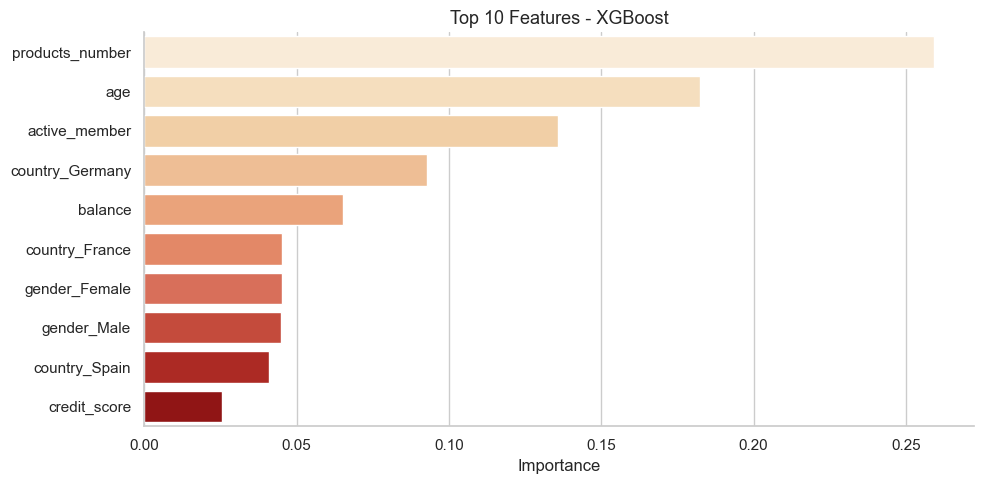

In [37]:
xgb_best = search_xgb.best_estimator_


ohe_features = (
    xgb_best.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_cols)
    .tolist()
)

feature_names = num_cols + ohe_features + binary_cols

importances = xgb_best.named_steps["model"].feature_importances_
feat_imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    hue=feat_imp.index,
    palette="OrRd",
    legend=False,
    ax=ax
)
ax.set_title("Top 10 Features - XGBoost", fontsize=13)
ax.set_xlabel("Importance")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

### Features
- The features seem to allign with our previous analysis of the most important features:
- Product_number is the most significant sign of churning (0.26). Clients that only use a single product have a weaker relationship and customers that use 3 products or more have a dramatically higher possibity of leaving the bank.
- Age is the second most relevant sign of churning (0.18). Which allign with the previous analysis of older customers have a different behaviour and churn more frequently than younger or elder clients.
- Active_Member is the third most relevant sign of churning (0.14). It is intuitive, clients that don't use the products of services are disengaged, and most likely to leave the bank.
- It is also interessing to point out than a customer being based in Germany has an considerable impact on whether they will churn(0.09), which may indicate and different profile of german customers in comparison to french or spanish clients.


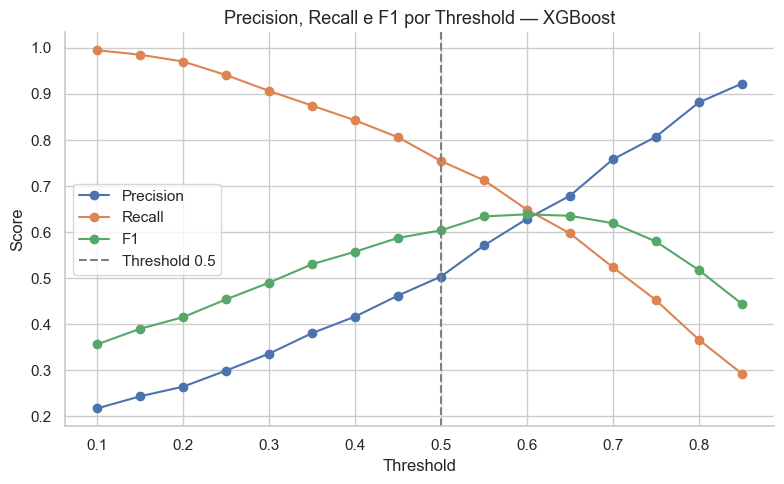

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5)) 

model_name = "XGBoost"
y_prob = y_prob_xgb 

results = []
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_prob >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    results.append({
        "threshold": t,
        "precision_churn": report["1"]["precision"],
        "recall_churn": report["1"]["recall"],
        "f1_churn": report["1"]["f1-score"]
    })

thresh_df = pd.DataFrame(results)
ax.plot(thresh_df["threshold"], thresh_df["precision_churn"], label="Precision", marker="o")
ax.plot(thresh_df["threshold"], thresh_df["recall_churn"],   label="Recall",    marker="o")
ax.plot(thresh_df["threshold"], thresh_df["f1_churn"],       label="F1",        marker="o")
ax.axvline(x=0.5, color="gray", linestyle="--", label="Threshold 0.5")
ax.set_title(f"Precision, Recall e F1 por Threshold — {model_name}", fontsize=13)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()

### Picking the Threshold
- In order to choose the threshold than best serve the purposes of this analysis, we have choose the 0.5 threshold as default, where the Recall is 0.68 and Precision is 0.52.
- However, we have decided to use the 0.45 threshold, where there is an higher Recall(0.80) and an lower Precision(0.45), which means the model will identify more churner customers at the cost of more false alarms. Nevertheless, we considered than the gain from an higher Recall is more advantageous to the bank, considering than the usually the cost of losing a client is more significant than a unecessary retention intervetion.

In [39]:
THRESHOLD = 0.45

y_pred_final = (y_prob_xgb >= THRESHOLD).astype(int)

report = classification_report(y_test, y_pred_final, target_names=["No Churn", "Churn"], output_dict=True)

summary_df = pd.DataFrame({
    "Metric": ["AUC-ROC", "AUC-PR", "Accuracy", "Threshold"],
    "Value":  [
        round(roc_auc_score(y_test, y_prob_xgb), 4),
        round(average_precision_score(y_test, y_prob_xgb), 4),
        round(report["accuracy"], 4),
        THRESHOLD
    ]
}).set_index("Metric")

metrics_df = pd.DataFrame({
    "Class":     ["No Churn", "Churn"],
    "Precision": [report["No Churn"]["precision"], report["Churn"]["precision"]],
    "Recall":    [report["No Churn"]["recall"],    report["Churn"]["recall"]],
    "F1-Score":  [report["No Churn"]["f1-score"],  report["Churn"]["f1-score"]],
    "Support":   [int(report["No Churn"]["support"]), int(report["Churn"]["support"])]
}).set_index("Class")

display(summary_df)
print()
display(metrics_df.style
    .format("{:.3f}", subset=["Precision", "Recall", "F1-Score"])
    .highlight_max(subset=["Precision", "Recall", "F1-Score"], color="lightgreen")
    .set_caption("Final Evaluation — XGBoost — Threshold 0.45")
)

,Value
Metric,
AUC-ROC,0.8665
AUC-PR,0.7159
Accuracy,0.7695
Threshold,0.4500


,Precision,Recall,F1-Score,Support
Class,,,,
No Churn,0.939,0.760,0.840,1593
Churn,0.462,0.806,0.587,407


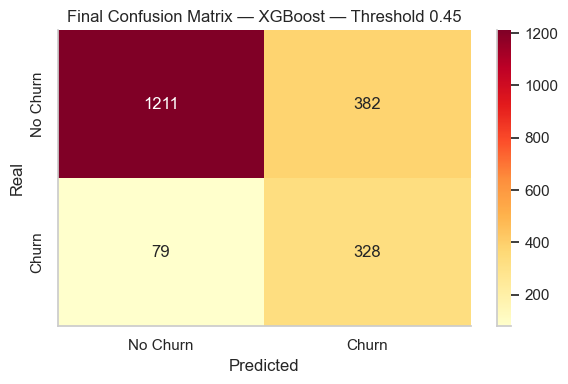

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
ax.set_title(f"Final Confusion Matrix — XGBoost — Threshold {THRESHOLD}", fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Real")
sns.despine()
plt.tight_layout()
plt.show()

## Conclusions and Recomendations

This project has sucessfuly developed and optimized a predictive model for customer churn in a banking context. The process was composed of a data cleaning, EDA, data preparation, pre-processing data, comparative model evaluation and model selection. We have arrived at a robust solution capable of identifying at-risk customers.

**Key Fidings**:
1. The model selected was the **XGBoost model**, who showed a superior perfomance compared to the Logistic Regression and Random Florest models, particularly at it's capacity of differentiating "Churn" and "No Churn" customers (AUC-ROC:0.867) and identifying the minority group(AUC-PR:0.715).
   
2. The most **relevant features**:
   - ***Product_numbers***: Clients who utilize 1 product have greater odds of churning and at 3 products or more, the churn rate rise sharply. Meanwhile, usage of 2 products may seem like the ideal value for the lowest churn rate.
   - ***Age***: Age-behavioural patterns strongly impacted the churn rate.
   - ***Active_Member***: A direct indicator, inactive customers are more likely to leave the bank.
   - ***Country***: Germany seems to have an unsually higher churn rate in comparison to others countries. May demand more investigation.

**Final Model Metrics**:
- AUC-ROC: 0.8665
- AUC-PR: 0.7159
- Accuracy: 0.7695
- Churn Recall: 0.806
- Churn Precision: 0.462

**Recomendations**:
1. Retention Campaigns: In light of the identified high-risk profile, it's suggested to implent campaigns focused towards that public in order to descrease the churn rate. Taking in consideration the high-recall value, those campaigns will most likely reach a significant portion of customers at high-risk of churning.
2. Age-specific engagement: Develop strategies that will be tailored for different age groups, especially thoses with a high churn risk.
3. Inactive-users engagement: Also develop strategies to re-engage inactive clients, as their inactiviness is a strong churn risk indicator.
4. Geographical analysis: German-based customers seem unsually prone to churn, it's relevant to investigate further the reasoning behind this occurrence. It may be necessary do an analysis of the local market conditions, competitors and products preference. 